# 07 — Looking at the cells behind three findings

A. **T-cell 18S polarity towards vessels** (notebook 06): perivascular T cells with their 18S polarity vector and
   the direction to the nearest vessel cell.
B. **Vimentin-high / RNA-quiet ("protein-only") astrocytes**: is the αSMA/Vim channel signal vimentin, or αSMA
   from an adjacent arteriole (VSMC)? Distance to the nearest VSMC by quadrant, and crops.
C. **18S texture vs clinical score** (notebook 05): 18S channel in the same cell type from the lowest- vs
   highest-score animal *within one section*, identical contrast.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu
from skimage.segmentation import find_boundaries

from beyondboundaries import data, plotting
from beyondboundaries import orthogonality as orth
from beyondboundaries.io import XeniumBundle, find_bundles

plotting.style()
SRC = "notebooks/07_visual_checks.ipynb"
OUT = ROOT / "results" / "07_visual_checks"
OUT.mkdir(parents=True, exist_ok=True)
CH = data.CHANNELS
PX = 0.2125
cfg = data.load_config()
bundles = find_bundles(cfg)
fa = pd.read_parquet(ROOT / "data" / "features_norm.parquet")
fa = fa[fa.segmentation_method == "Segmented by interior stain (18S)"].copy()
_open = {}


def bundle(sec):
    if sec not in _open:
        _open[sec] = XeniumBundle(bundles[sec])
    return _open[sec]


def raw_hi(ch, q=99.5):
    v = fa[f"{ch}_cell_p99"] * fa[f"{ch}_scale"] + fa[f"{ch}_bg_local"]
    return np.nanpercentile(v, q)


HI = [raw_hi(ch) for ch in CH]


def crop(row, half_um=20):
    h = int(half_um / PX)
    y, x = int(row.centroid_y_px), int(row.centroid_x_px)
    img, cm, nm = bundle(row.section_id).read_window(y - h, x - h, 2 * h, 2 * h)
    return img, cm, nm, h

## A. Perivascular T cells: 18S polarity (yellow) vs direction to nearest vessel cell (cyan)

perivascular T cells: 4,163; cos towards vessel: mean 0.134, strongly polarised subset mean 0.204


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/07_visual_checks/tcell_perivascular_polarity.png')

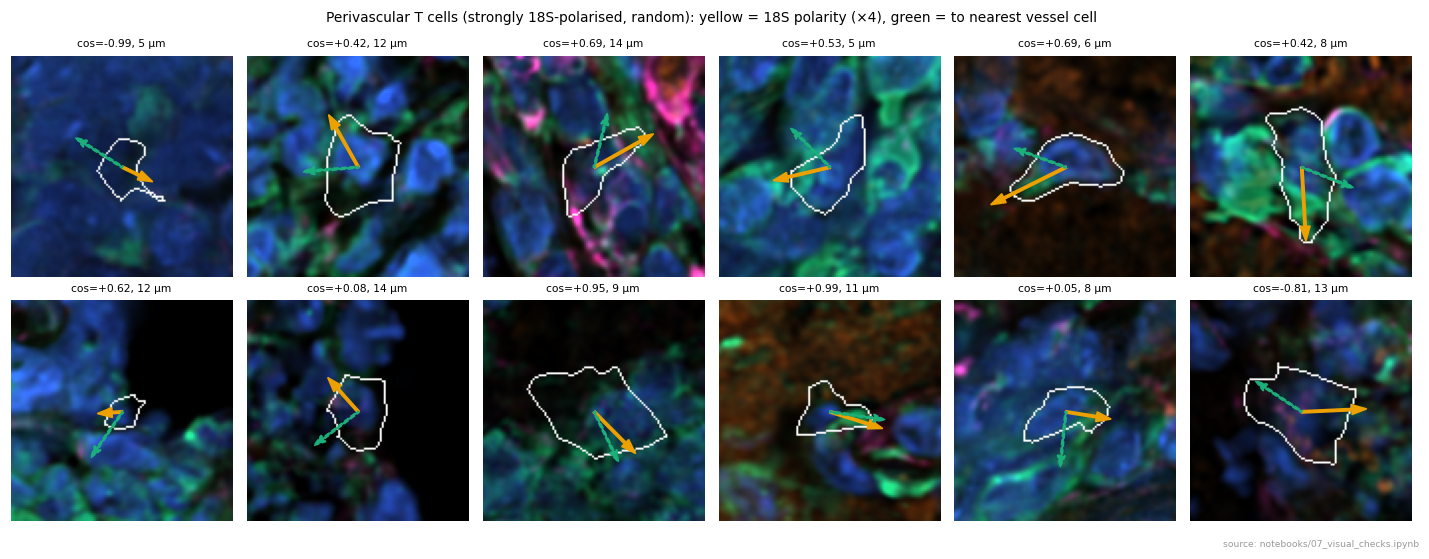

In [2]:
vessel = fa.Anno_L1_curated.isin(["Endothelial", "VSMC"]).values
nv = orth.nearest_of(fa, vessel)
fa = fa.join(nv.add_prefix("vessel_"))
t = fa[(fa.Anno_L1_curated == "T cell") & (fa.vessel_dist_um < 15)].copy()
t["cos"] = (t.r18s_polarity_dx_um * t.vessel_dx_um + t.r18s_polarity_dy_um * t.vessel_dy_um) / (
    np.hypot(t.r18s_polarity_dx_um, t.r18s_polarity_dy_um) * np.hypot(t.vessel_dx_um, t.vessel_dy_um))
# strongly polarised cells (top quartile of 18S polarity), random order — not cherry-picked by direction
pick = t[t.r18s_polarity_shape > t.r18s_polarity_shape.quantile(0.75)].sample(12, random_state=0)
print(f"perivascular T cells: {len(t):,}; cos towards vessel: mean {t.cos.mean():.3f}, "
      f"strongly polarised subset mean {t.loc[t.r18s_polarity_shape > t.r18s_polarity_shape.quantile(0.75), 'cos'].mean():.3f}")
fig, axs = plt.subplots(2, 6, figsize=(13, 5))
for ax, (_, row) in zip(axs.ravel(), pick.iterrows()):
    img, cm, nm, h = crop(row, 12)
    rgb = plotting.composite(img, CH, [0] * 4, HI)
    rgb[find_boundaries(cm == cm[h, h], mode="inner")] = 1
    ax.imshow(rgb)
    s = 3 / PX  # arrow length scale: 3 µm polarity -> px
    ax.arrow(h, h, row.r18s_polarity_dx_um / PX * 4, row.r18s_polarity_dy_um / PX * 4, color="#eda100", width=1.2,
             head_width=5, length_includes_head=True)
    v = np.array([row.vessel_dx_um, row.vessel_dy_um]) / max(np.hypot(row.vessel_dx_um, row.vessel_dy_um), 1e-6) * s * 2
    ax.arrow(h, h, v[0], v[1], color="#1baf7a", width=1.0, head_width=4, length_includes_head=True, ls="--")
    ax.set_title(f"cos={row.cos:+.2f}, {row.vessel_dist_um:.0f} µm", fontsize=7)
    ax.axis("off")
fig.suptitle("Perivascular T cells (strongly 18S-polarised, random): yellow = 18S polarity (×4), green = to nearest vessel cell",
             fontsize=9)
fig.tight_layout()
plotting.save_fig(fig, "tcell_perivascular_polarity", OUT, SRC)

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/07_visual_checks/tcell_polarity_cos_hist.png')

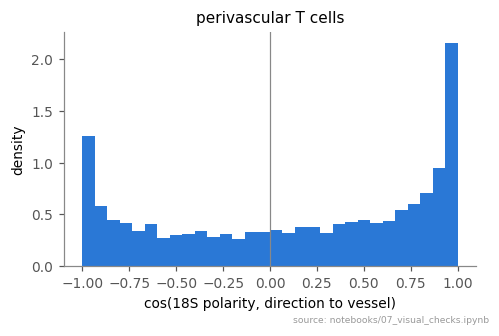

In [3]:
fig, ax = plt.subplots(figsize=(4.5, 3))
ax.hist(t.cos.dropna(), bins=30, color=plotting.CATEGORICAL[0], density=True)
ax.axvline(0, color="#888888", lw=0.8)
ax.set(xlabel="cos(18S polarity, direction to vessel)", ylabel="density", title="perivascular T cells")
fig.tight_layout()
plotting.save_fig(fig, "tcell_polarity_cos_hist", OUT, SRC)

> **Finding — perivascular T cells polarise 18S towards the vessel.** Mean cos(18S polarity, direction to nearest vessel
> cell) = 0.13 over 4,163 perivascular T cells, 0.20 in the most polarised quarter; in the random gallery 9 of 12
> point roughly vessel-wards. (Neurons and oligodendrocytes next to vessels show no such bias — notebook 06.)

## B. Vimentin-high / RNA-quiet astrocytes vs VSMC proximity
If the "protein-only" αSMA/Vim signal is αSMA from an adjacent arteriole, these astrocytes should sit closer to
VSMCs than other astrocytes and the signal should sit at the VSMC side.

In [4]:
aq = pd.read_parquet(ROOT / "data" / "astro_quadrants.parquet")
ast = fa.join(aq, how="inner")
vs = orth.nearest_of(fa, (fa.Anno_L1_curated == "VSMC").values)
ast = ast.join(vs.add_prefix("vsmc_"))
ast["smavim_cos_vsmc"] = (ast.smavim_polarity_dx_um * ast.vsmc_dx_um + ast.smavim_polarity_dy_um * ast.vsmc_dy_um) / (
    np.hypot(ast.smavim_polarity_dx_um, ast.smavim_polarity_dy_um) * np.hypot(ast.vsmc_dx_um, ast.vsmc_dy_um))
QUADS = ["both high", "protein-only", "RNA-only", "both low", "middle"]
vt = ast.groupby("quadrant").agg(n=("vsmc_dist_um", "size"), vsmc_dist_median=("vsmc_dist_um", "median"),
                                 frac_vsmc_within_10um=("vsmc_dist_um", lambda s: (s < 10).mean()),
                                 smavim_towards_vsmc_cos=("smavim_cos_vsmc", "mean")).loc[QUADS]
p = mannwhitneyu(ast.loc[ast.quadrant == "protein-only", "vsmc_dist_um"].dropna(),
                 ast.loc[ast.quadrant == "both low", "vsmc_dist_um"].dropna()).pvalue
print(f"protein-only vs both-low VSMC distance: MWU p = {p:.2g}")
vt.to_csv(OUT / "astro_quadrant_vsmc_proximity.csv")
vt.round(3)

protein-only vs both-low VSMC distance: MWU p = 0.4


,n,vsmc_dist_median,frac_vsmc_within_10um,smavim_towards_vsmc_cos
quadrant,,,,
both high,5853,132.529,0.004,0.018
protein-only,401,57.860,0.070,0.010
RNA-only,1312,120.715,0.005,0.022
both low,4833,58.080,0.015,0.022
middle,34663,75.266,0.017,0.022


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/07_visual_checks/astro_protein_only_vsmc_gallery.png')

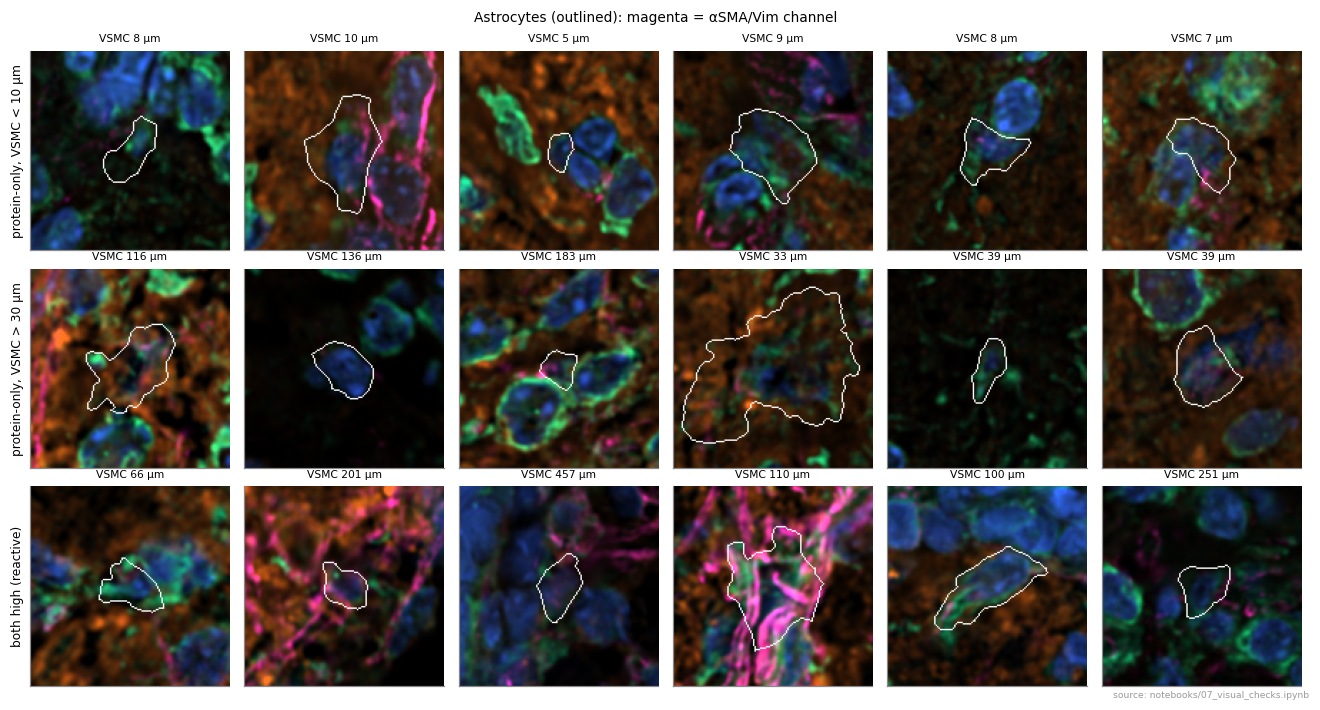

In [5]:
po = ast[ast.quadrant == "protein-only"]
rows = [("protein-only, VSMC < 10 µm", po[po.vsmc_dist_um < 10]), ("protein-only, VSMC > 30 µm", po[po.vsmc_dist_um > 30]),
        ("both high (reactive)", ast[ast.quadrant == "both high"])]
fig, axs = plt.subplots(3, 6, figsize=(12, 6.4))
for r, (lab, d) in enumerate(rows):
    d = d.sample(min(6, len(d)), random_state=0)
    for c, (_, row) in enumerate(d.iterrows()):
        img, cm, nm, h = crop(row, 15)
        rgb = plotting.composite(img, CH, [0] * 4, HI)
        rgb[find_boundaries(cm == cm[h, h], mode="inner")] = 1
        axs[r, c].imshow(rgb); axs[r, c].set_xticks([]); axs[r, c].set_yticks([])
        axs[r, c].set_title(f"VSMC {row.vsmc_dist_um:.0f} µm", fontsize=7)
    for c in range(len(d), 6):
        axs[r, c].axis("off")
    axs[r, 0].set_ylabel(lab, fontsize=8)
fig.suptitle("Astrocytes (outlined): magenta = αSMA/Vim channel", fontsize=9)
fig.tight_layout()
plotting.save_fig(fig, "astro_protein_only_vsmc_gallery", OUT, SRC)

> **Finding — "protein-only" astrocytes are mostly real vimentin, not arteriole αSMA.** Their median distance to the
> nearest VSMC equals that of quiet astrocytes (58 vs 58 µm, p = 0.4) and their αSMA/Vim signal does not lean towards
> the VSMC (cos 0.01). A minority (7 %) sit within 10 µm of a VSMC (vs 1.5 % of quiet astrocytes) — that subset may
> carry smooth-muscle αSMA.

## C. 18S texture: lowest- vs highest-score animal in the same section
Section with the widest score range among its animals; myeloid cells and astrocytes; 18S channel only (grey),
identical contrast; median texture correlation per animal in the titles.

run5_C2_G3_Top_0088870 animals: {'C_CFA_6': {'score': 0.0, 'n': 10006}, 'C_NS_5': {'score': 0.0, 'n': 6735}, 'C_P1_6': {'score': 3.25, 'n': 17493}}


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/07_visual_checks/r18s_texture_low_vs_high_score.png')

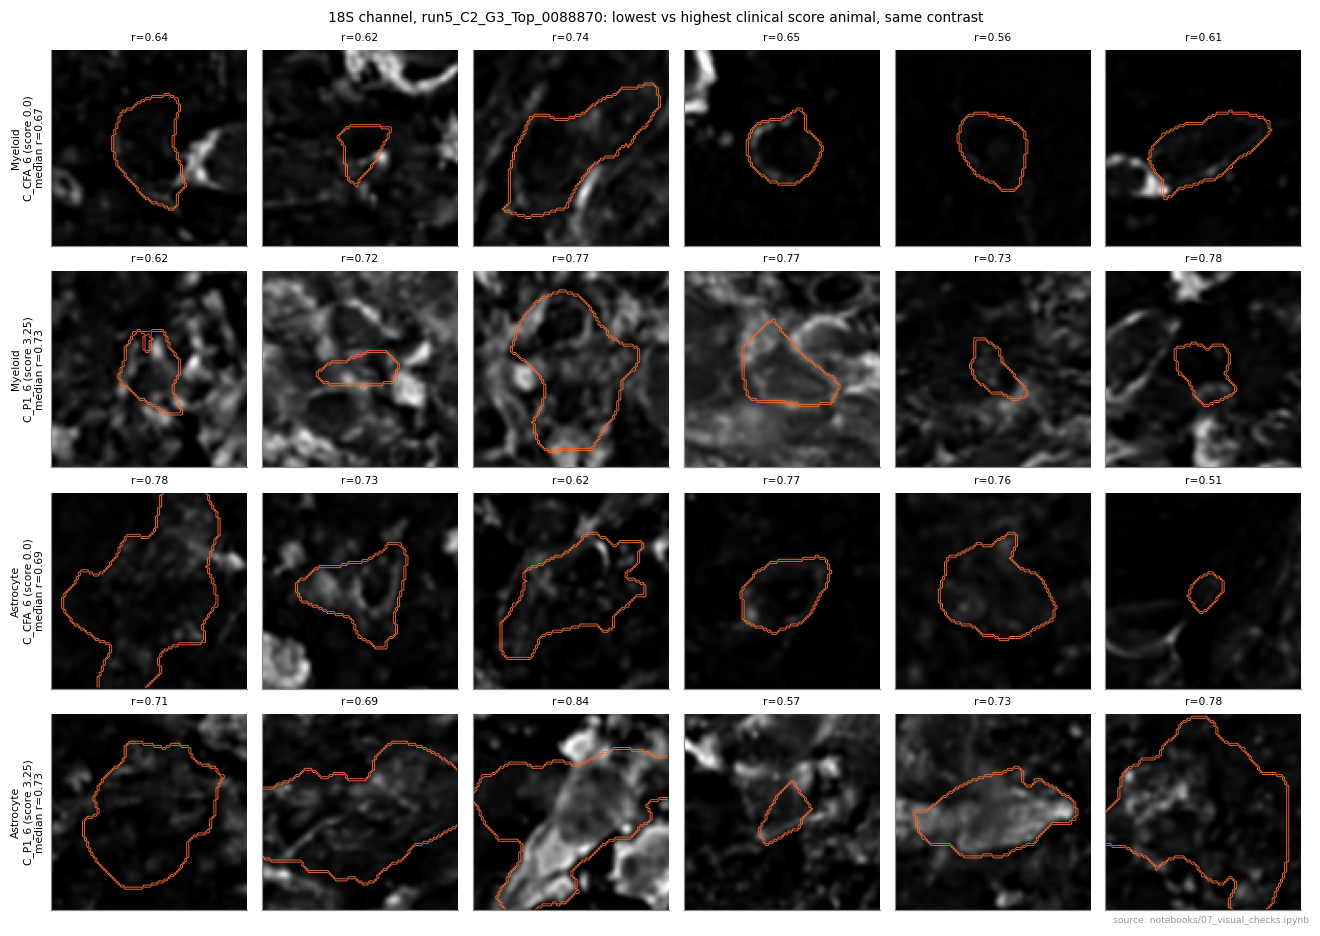

In [6]:
lum = fa[fa.region == "L"]
rng_ = lum.groupby("section_id").score_sacrifice.agg(lambda s: s.max() - s.min())
SEC = rng_.idxmax()
an = lum[lum.section_id == SEC].groupby("sample_name", observed=True).agg(score=("score_sacrifice", "first"),
                                                                          n=("section_id", "size"))
an = an[an.n >= 500].sort_values("score")
lo_an, hi_an = an.index[0], an.index[-1]
print(SEC, "animals:", an.to_dict("index"))
hi18 = raw_hi("r18s", 99)
fig, axs = plt.subplots(4, 6, figsize=(12, 8.5))
for r, (ct, animal) in enumerate([(ct, a_) for ct in ("Myeloid", "Astrocyte") for a_ in (lo_an, hi_an)]):
    d = lum[(lum.section_id == SEC) & (lum.sample_name == animal) & (lum.Anno_L1_curated == ct)]
    med = d.r18s_glcm_correlation.median()
    for c, (_, row) in enumerate(d.sample(min(6, len(d)), random_state=0).iterrows()):
        img, cm, nm, h = crop(row, 10)
        axs[r, c].imshow(img[2], cmap="gray", vmin=0, vmax=hi18)
        axs[r, c].contour(find_boundaries(cm == cm[h, h], mode="inner"), levels=[0.5], colors="#eb6834", linewidths=0.6)
        axs[r, c].set_xticks([]); axs[r, c].set_yticks([])
        axs[r, c].set_title(f"r={row.r18s_glcm_correlation:.2f}", fontsize=7)
    axs[r, 0].set_ylabel(f"{ct}\n{animal} (score {an.loc[animal, 'score']})\nmedian r={med:.2f}", fontsize=7)
fig.suptitle(f"18S channel, {SEC}: lowest vs highest clinical score animal, same contrast", fontsize=9)
fig.tight_layout()
plotting.save_fig(fig, "r18s_texture_low_vs_high_score", OUT, SRC)

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/07_visual_checks/r18s_texture_per_animal_hist.png')

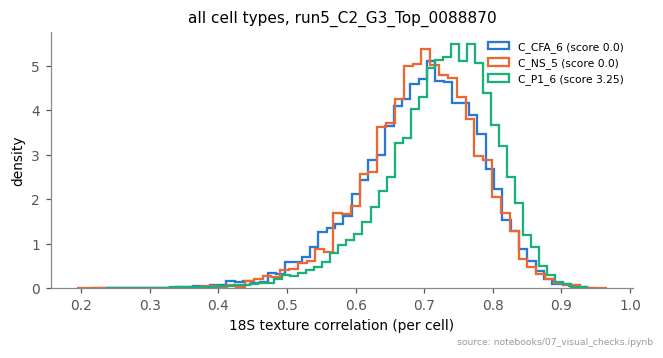

In [7]:
# per-animal distributions within this section, all cell types
d = lum[(lum.section_id == SEC) & lum.sample_name.isin(an.index)]
fig, ax = plt.subplots(figsize=(6, 3.2))
for k, a_ in enumerate(an.index):
    v = d.loc[d.sample_name == a_, "r18s_glcm_correlation"].dropna()
    ax.hist(v, bins=60, density=True, histtype="step", lw=1.5, color=plotting.CATEGORICAL[k % 8],
            label=f"{a_} (score {an.loc[a_, 'score']})")
ax.set(xlabel="18S texture correlation (per cell)", ylabel="density", title=f"all cell types, {SEC}")
ax.legend(fontsize=7)
fig.tight_layout()
plotting.save_fig(fig, "r18s_texture_per_animal_hist", OUT, SRC)

> **Finding — what the 18S-texture difference looks like.** In the same section (run5_C2_G3_Top), the highest-score
> animal (C_P1_6, score 3.25) shows smoother, larger-scale 18S structures inside cells than the CFA animal (median
> texture correlation 0.73 vs 0.67 in myeloid cells, 0.73 vs 0.69 in astrocytes) — and many more bright 18S
> structures *around* cells (infiltrate), which motivated the next test.

### Is the 18S-texture signal intracellular, or neighbour crowding?
The images suggest sicker animals have more bright 18S structures *around* cells (infiltrates). Bright neighbours
bleeding across a cell's outline would also raise texture correlation (smoother, larger-scale gradients). Test: within
each cell type (lumbar), regress per-cell 18S texture correlation on neighbouring 18S (raw ring and territory),
local cell density (cells within 20 µm) and cell area; then repeat the within-section animal-level test on the
residual. If the score link disappears, the "biomarker" is crowding, not intracellular ribosome organisation.

                 ρ ring 18S  ρ territory 18S  ρ local density  \
cell_type                                                       
Myeloid               0.153            0.132            0.180   
Astrocyte             0.131            0.095            0.117   
Endothelial           0.104            0.069            0.203   
Fibroblast            0.086            0.062            0.125   
Oligodendrocyte       0.181            0.176            0.090   
Neuron                0.218            0.190           -0.142   

                 R² of covariates  
cell_type                          
Myeloid                     0.232  
Astrocyte                   0.242  
Endothelial                 0.209  
Fibroblast                  0.167  
Oligodendrocyte             0.258  
Neuron                      0.325  


,cell_type,version,rho_all,rho_within_section
0,Myeloid,raw texture,0.76,0.84
1,Myeloid,adjusted for neighbours/density,0.68,0.69
2,Astrocyte,raw texture,0.72,0.84
3,Astrocyte,adjusted for neighbours/density,0.54,0.77
4,Endothelial,raw texture,0.70,0.82
5,Endothelial,adjusted for neighbours/density,0.44,0.81
6,Fibroblast,raw texture,0.69,0.67
7,Fibroblast,adjusted for neighbours/density,0.51,0.75
8,Oligodendrocyte,raw texture,0.50,0.53
9,Oligodendrocyte,adjusted for neighbours/density,0.38,0.45


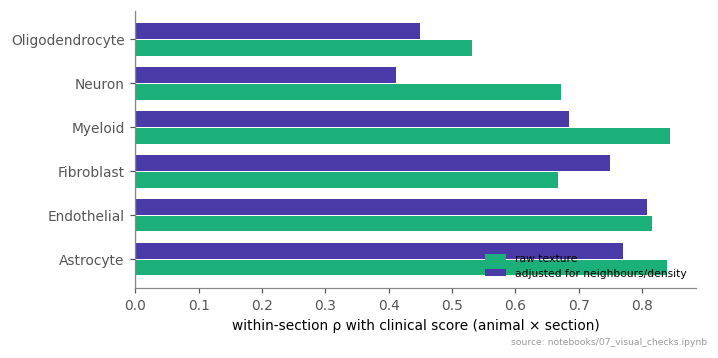

In [8]:
from scipy.spatial import cKDTree
from scipy.stats import spearmanr

dens = pd.Series(np.nan, index=fa.index)
for _, idx in fa.groupby("section_id", observed=True).indices.items():
    xy = fa[["x_centroid", "y_centroid"]].values[idx]
    dens.iloc[idx] = [len(n) - 1 for n in cKDTree(xy).query_ball_point(xy, r=20)]
fa["local_density"] = dens
lum = fa[fa.region == "L"].copy()
for comp in ("ring", "terr"):
    lum[f"r18s_{comp}_raw"] = lum[f"r18s_{comp}_mean"] * lum.r18s_scale + lum.r18s_bg_local
rows, cov_r = [], []
for ct in ["Myeloid", "Astrocyte", "Endothelial", "Fibroblast", "Oligodendrocyte", "Neuron"]:
    d = lum[lum.Anno_L1_curated == ct].dropna(subset=["r18s_glcm_correlation", "r18s_ring_raw", "r18s_terr_raw"]).copy()
    Xc = np.c_[np.log1p(d.r18s_ring_raw.clip(lower=0)), np.log1p(d.r18s_terr_raw.clip(lower=0)),
               np.log1p(d.local_density), np.log(d.morph_cell_area_um2), np.ones(len(d))]
    beta, *_ = np.linalg.lstsq(Xc, d.r18s_glcm_correlation.values, rcond=None)
    d["tex_adj"] = d.r18s_glcm_correlation - Xc @ beta
    cov_r.append({"cell_type": ct, **{k: spearmanr(d.r18s_glcm_correlation, v).statistic for k, v in
                                     (("ρ ring 18S", d.r18s_ring_raw), ("ρ territory 18S", d.r18s_terr_raw),
                                      ("ρ local density", d.local_density))},
                  "R² of covariates": 1 - d.tex_adj.var() / d.r18s_glcm_correlation.var()})
    for col in ("r18s_glcm_correlation", "tex_adj"):
        a = d.groupby(["section_id", "sample_name"], observed=True).agg(v=(col, "median"), score=("score_sacrifice", "first"),
                                                                         n=("section_id", "size")).reset_index()
        a = a[a.n >= 30]
        a["v_w"] = a.v - a.groupby("section_id").v.transform("mean")
        a["s_w"] = a.score - a.groupby("section_id").score.transform("mean")
        b = a[(a.groupby("section_id").sample_name.transform("nunique") > 1) & (a.groupby("section_id").score.transform("std") > 0)]
        rows.append(dict(cell_type=ct, version="raw texture" if col == "r18s_glcm_correlation" else "adjusted for neighbours/density",
                         rho_all=spearmanr(a.v, a.score).statistic, rho_within_section=spearmanr(b.v_w, b.s_w).statistic))
crowd = pd.DataFrame(rows)
crowd.to_csv(OUT / "r18s_texture_crowding_adjustment.csv", index=False)
display_cov = pd.DataFrame(cov_r).set_index("cell_type").round(3)
print(display_cov)
pv = crowd.pivot(index="cell_type", columns="version", values="rho_within_section")
fig, ax = plt.subplots(figsize=(6.5, 3.2))
y = np.arange(len(pv))
for k, c in enumerate(["raw texture", "adjusted for neighbours/density"]):
    ax.barh(y + (k - 0.5) * 0.38, pv[c], height=0.36, color=plotting.CATEGORICAL[[2, 6][k]], label=c)
ax.axvline(0, color="#888888", lw=0.8)
ax.set_yticks(y, pv.index); ax.set_xlabel("within-section ρ with clinical score (animal × section)")
ax.legend(fontsize=7, loc="lower right")
fig.tight_layout()
plotting.save_fig(fig, "r18s_texture_crowding_adjustment", OUT, SRC)
crowd.round(2)

> **Finding — the 18S-texture severity signal is mostly not neighbour crowding.** Neighbouring 18S brightness, local
> cell density and cell size explain 17–33 % of per-cell texture variance, but after removing them the within-section
> association with clinical score largely remains (ρ 0.41–0.81 vs 0.53–0.86 raw; endothelium 0.82 → 0.81, astrocytes
> 0.84 → 0.77, myeloid 0.84 → 0.69). Still a candidate needing replication in another run.